## Building probabaility rank a matrix and seeing how it does with ARI
##### With this trial we aim to gather ground-truth blobs from the sklearn datasets, then we will add random gaussian noise to each of these points to simulate our observed blobs, using these observed blobs we will run a Monte Carlo simulation to then compare it to our ground-truth blobs using ARI 

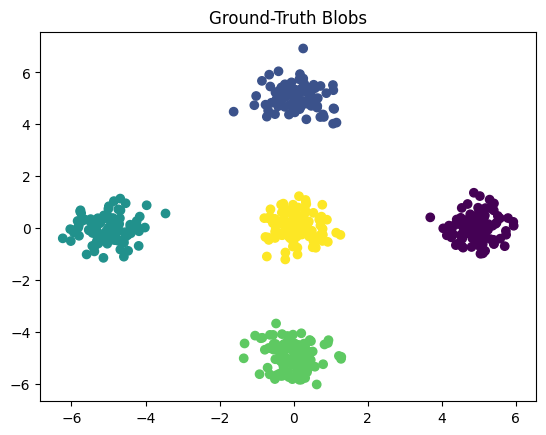

In [72]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, true_labels = make_blobs(
    n_samples = 500,
    centers = [(5, 0), (0, 5), (-5, 0), (0, -5), (0, 0)],
    cluster_std = 0.5,
    random_state = 42
)

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show ()

### Now we simulate a noise model 
##### We do this by adding random gaussian noise to each point of X simulating our observed X, which is what we will use for our Monte Carlo simulation

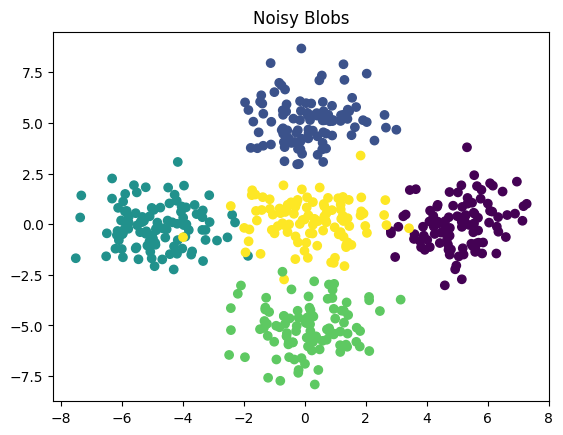

In [73]:
import numpy as np

std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

### With this noise model we can run a Monte Carlo simulation to build our probability rank matrix

In [ ]:
n, _ = X.shape # we have _ because we only care about our noisy datapoints
sims = 1000 # number of monte carlo sims
k = 5 # k-nearest neighbours

matrix = np.zeros((n, n), dtype=int)

for t in range(sims):

    X_obs = X + np.random.normal(scale=std, size=X.shape) # making the noisy points every time the sim is ran

    x = np.linalg.norm(X_obs[:,None,:] - X_obs[None,:,:], axis=2) # euclidian norm of the distance between i and j

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            num_closer = (x[i] < x[i, j]).sum() 
            if num_closer - 1 >= k:  
                matrix[i, j] += 1

M = matrix/sims # normalize matrix to get the average of every M[i, j] (which is the proabability of at least k neighbours being closer to i than j is)

### Running HDBSCAN with our probability rank matrix, and evaluating perfromance with ARI (Adjusted Rand Index)

In [ ]:
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance

X_obs_fixed = X + np.random.normal(scale=std, size=X.shape)

nbrs = NearestNeighbors(n_neighbors=n).fit(X_obs_fixed)
distances, neighbors = nbrs.kneighbors(X_obs_fixed)

core_dist_unc = np.zeros(n, dtype=float)

for i in range(n):
    total = 0.0
    for idx in range(distances.shape[1]):
        j = neighbors[i, idx]
        if j == i:
            continue
        total += M[i, j]
        if total >= k:
            core_dist_unc[i] = distances[i, idx]
            break
    else:
        core_dist_unc[i] = distances[i, -1]

d_obs = np.linalg.norm(
    X_obs_fixed[:, None, :] - X_obs_fixed[None, :, :],
    axis=2
)

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

assert cd_i.shape == (n, 1) and cd_j.shape == (1, n)

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',     
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(labels_true=true_labels, labels_pred=pred_labels)
print("ARI (uncertainty-aware):", ari)

ARI (uncertainty-aware): 0.735588052932793


#### 500 sims trial results (std = 0.8):
- Trial 1: 0.9250794289206326
- Trial 2: 0.8295079428920632
- Trial 3: 0.9212621300692903

#### 1000 sims trial results (std = 0.8):
- Trial 1: 0.9054612129872843
- Trial 2: 0.9700565392394662
- Trial 3: 0.8670997222911438

#### 500 sims trial results (std = 2.8):
- 0.05942133072627401
- 0.0013804297424590555
- 0.01983713894644029

#### 1000 sims trial results (std = 2.8):
-  0.03861092582237194
- -0.0010415369696543863
- 0.0011931716654722973

#### Trials for 1000 sims with added blob in middle of dataset with 0.5 std:
- 0.6025770733876528
- 0.735588052932793
- 

#### Trials for 1000 sims with added blob in middle of dataset with 1.5 std:
- 

To do: Do more simulations with different levels of standard deviation, and different levels of gaussian noise